# Plurality with Closed Primaries vs IRV with a Top-Four Open Primary

This notebook compares a **Plurality general election with plurality closed primaries** against an **IRV general election with a top-four open primary** pipeline across several two-party electorate scenarios and several voting strategies.

The comparison here is based on a **single simulation draw per scenario**, not a Monte Carlo average.

For the two pipelines used here:

- **Plurality + closed primaries**: each party runs a plurality closed primary, then the nominees face each other in a plurality general election.
- **IRV + top-four open primary**: all candidates compete in a single plurality open primary, the **top four** advance, and the general election among those finalists uses IRV.


---
## 0. Imports and configuration

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

cwd = Path.cwd().resolve()
if (cwd / "configs").exists() and (cwd / "electoral_sim").exists():
    REPO_ROOT = cwd
else:
    REPO_ROOT = cwd.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from electoral_sim.ballots import BallotProfile
from electoral_sim.candidates import CandidateSet, from_config as candidates_from_config
from electoral_sim.electorate import Electorate, from_config as electorate_from_config
from electoral_sim.metrics import compute_metrics
from electoral_sim.primaries import PartySpec, assign_party_membership, PrimaryType
from electoral_sim.strategies import (
    PluralityCompromiseStrategy,
    RankedBuryingStrategy,
    RankedTruncationStrategy,
    SincereStrategy,
    TurnoutStrategy,
    VotingContext,
)
from electoral_sim.systems import InstantRunoff, Plurality

sns.set_theme(style="whitegrid")

RNG_SEED = 42
SCENARIOS_DIR = REPO_ROOT / "configs" / "scenarios"
SCENARIO_FILES = [
    "primary_01_symmetric_polarized.yaml",
    "primary_02_centrist_majority.yaml",
    "primary_03_dominant_left.yaml",
    "primary_04_high_overlap.yaml",
    "primary_05_diagonal_crosspressured.yaml",
    "primary_06_factionalized_majority.yaml",
    "primary_07_three_dimensional_competition.yaml",
    "primary_08_insurgent_outlier.yaml",
    
]

---
## 1. Load primary scenarios

In [2]:
def load_primary_scenario(path: Path, rng=None):
    with open(path) as f:
        config = yaml.safe_load(f)

    electorate = electorate_from_config(config, rng=rng)
    candidates = candidates_from_config(config)
    parties = []
    for _, party_conf in config["parties"].items():
        parties.append(
            PartySpec(
                name=party_conf["name"],
                candidate_indices=party_conf["candidate_indices"],
                primary_system=Plurality(),
            )
        )
    return config, electorate, candidates, parties


scenario_bundle = []
for idx, filename in enumerate(SCENARIO_FILES):
    cfg, electorate, candidates, parties = load_primary_scenario(
        SCENARIOS_DIR / filename,
        rng=np.random.default_rng(RNG_SEED + idx),
    )
    scenario_bundle.append((cfg, electorate, candidates, parties))

for cfg, electorate, candidates, parties in scenario_bundle:
    print(
        f"{cfg['name']:<35} voters={electorate.n_voters:<5} candidates={candidates.n_candidates} parties={len(parties)}"
    )

Two-Party Symmetric Polarized       voters=6000  candidates=6 parties=2
Two-Party Asymmetric Centrist Majority voters=6000  candidates=6 parties=2
Two-Party Dominant Left             voters=6000  candidates=7 parties=2
Two-Party High Overlap              voters=6000  candidates=6 parties=2
Two-Party Diagonal Cross-Pressures  voters=6000  candidates=6 parties=2
Factionalized Majority Party        voters=7000  candidates=8 parties=2
Three-Dimensional Primary Competition voters=6500  candidates=6 parties=2
Insurgent Outlier Candidate         voters=6000  candidates=6 parties=2


---
## 2. Define strategy suite

The same strategy label is applied to both sides of the comparison. Some strategies mostly affect Plurality, some mostly affect IRV, and turnout affects both.

In [3]:
def make_strategies(seed: int):
    return {
        "Sincere": SincereStrategy(),
        "Plurality compromise": PluralityCompromiseStrategy(
            compromise_rate=1.0,
            viability_threshold=0.15,
            frontrunner_count=2,
            rng=np.random.default_rng(seed),
        ),
        "Ranked truncation": RankedTruncationStrategy(max_ranked=2),
        "Ranked burying": RankedBuryingStrategy(
            bury_rate=1.0,
            viability_threshold=0.15,
            frontrunner_count=2,
            rng=np.random.default_rng(seed),
        ),
        "Turnout shock": TurnoutStrategy(
            turnout_probability=0.80,
            abstain_if_favorite_nonviable=True,
            abstain_probability_when_nonviable=1.0,
            viability_threshold=0.15,
            frontrunner_count=2,
            rng=np.random.default_rng(seed),
        ),
    }


list(make_strategies(RNG_SEED).keys())

['Sincere',
 'Plurality compromise',
 'Ranked truncation',
 'Ranked burying',
 'Turnout shock']

---
## 3. Helper functions

We evaluate two institutional pipelines on the same electorate draw:

1. **Plurality + closed primaries**: plurality primary in each party, then plurality among the nominees.
2. **IRV + top-four open primary**: a single plurality open primary over the full candidate field, then IRV among the top four finishers.

Polling context, when used, is generated from sincere plurality shares for the relevant electorate/candidate set.


In [4]:
def sincere_poll_context(electorate, candidates):
    ballots = BallotProfile.from_preferences(electorate, candidates)
    poll_shares = ballots.plurality_counts() / max(ballots.n_active_voters, 1)
    return VotingContext(poll_shares=poll_shares)


def maybe_context(strategy_name, electorate, candidates):
    if strategy_name in {"Plurality compromise", "Ranked burying", "Turnout shock"}:
        return sincere_poll_context(electorate, candidates)
    return None


def mean_pairwise_distance(positions):
    if len(positions) < 2:
        return 0.0
    distances = []
    for i in range(len(positions)):
        for j in range(i + 1, len(positions)):
            distances.append(np.linalg.norm(positions[i] - positions[j]))
    return float(np.mean(distances))


def run_primary_pipeline(
    electorate,
    candidates,
    parties,
    strategy_name,
    strategy_factory,
    primary_type,
    general_system,
    pipeline_name,
    seed,
):
    memberships = assign_party_membership(
        electorate,
        candidates,
        parties,
        primary_type=primary_type,
    )
    party_results = []

    for p_idx, party in enumerate(parties):
        voter_mask = memberships[party.name]
        primary_electorate = Electorate(
            electorate.preferences[voter_mask],
            dim_names=electorate.dim_names,
        )
        party_positions = candidates.positions[party.candidate_indices]
        party_labels = [candidates.labels[i] for i in party.candidate_indices]
        party_candidates = CandidateSet(party_positions, party_labels)

        primary_strategy = strategy_factory(seed + 10 + p_idx)
        primary_context = maybe_context(strategy_name, primary_electorate, party_candidates)
        primary_ballots = BallotProfile.from_strategy(
            primary_electorate,
            party_candidates,
            strategy=primary_strategy,
            context=primary_context,
        )
        primary_result = Plurality().run(primary_ballots, party_candidates)
        nominee_local_idx = primary_result.winner_indices[0]
        nominee_global_idx = party.candidate_indices[nominee_local_idx]

        party_results.append(
            {
                "party": party.name,
                "nominee_index": nominee_global_idx,
                "nominee_label": candidates.labels[nominee_global_idx],
            }
        )

    nominee_positions = np.array([
        candidates.positions[item["nominee_index"]] for item in party_results
    ])
    nominee_labels = [
        f"{item['party']} nominee ({item['nominee_label']})" for item in party_results
    ]
    nominee_candidates = CandidateSet(nominee_positions, nominee_labels)

    general_strategy = strategy_factory(seed + 99)
    general_context = maybe_context(strategy_name, electorate, nominee_candidates)
    general_ballots = BallotProfile.from_strategy(
        electorate,
        nominee_candidates,
        strategy=general_strategy,
        context=general_context,
    )
    general_result = general_system.run(general_ballots, nominee_candidates)
    general_metrics = compute_metrics(general_result, electorate, nominee_candidates)

    nominee_names = [item["nominee_label"] for item in party_results]
    divergence = float(np.linalg.norm(nominee_positions[0] - nominee_positions[1]))

    return {
        "pipeline": pipeline_name,
        "winner": nominee_candidates.labels[general_result.winner_indices[0]],
        "distance_to_median": general_metrics.distance_to_median,
        "distance_to_mean": general_metrics.distance_to_mean,
        "majority_satisfaction": general_metrics.majority_satisfaction,
        "mean_voter_distance": general_metrics.mean_voter_distance,
        "active_voters": general_ballots.n_active_voters,
        "nominees": " vs ".join(nominee_names),
        "nominee_divergence": divergence,
    }


def run_plurality_closed_primary(electorate, candidates, parties, strategy_name, strategy_factory, seed):
    return run_primary_pipeline(
        electorate,
        candidates,
        parties,
        strategy_name,
        strategy_factory,
        primary_type=PrimaryType.CLOSED,
        general_system=Plurality(),
        pipeline_name="Plurality + closed primary",
        seed=seed,
    )


def run_irv_top4_open_primary(electorate, candidates, strategy_name, strategy_factory, seed, top_k=4):
    primary_strategy = strategy_factory(seed + 10)
    primary_context = maybe_context(strategy_name, electorate, candidates)
    primary_ballots = BallotProfile.from_strategy(
        electorate,
        candidates,
        strategy=primary_strategy,
        context=primary_context,
    )

    vote_counts = primary_ballots.plurality_counts()
    finalist_indices = np.argsort(-vote_counts, kind="stable")[: min(top_k, candidates.n_candidates)]
    finalist_positions = candidates.positions[finalist_indices]
    finalist_labels = [candidates.labels[idx] for idx in finalist_indices]
    finalist_candidates = CandidateSet(finalist_positions, finalist_labels)

    general_strategy = strategy_factory(seed + 99)
    general_context = maybe_context(strategy_name, electorate, finalist_candidates)
    general_ballots = BallotProfile.from_strategy(
        electorate,
        finalist_candidates,
        strategy=general_strategy,
        context=general_context,
    )
    general_result = InstantRunoff().run(general_ballots, finalist_candidates)
    general_metrics = compute_metrics(general_result, electorate, finalist_candidates)

    return {
        "pipeline": "IRV + top-four open primary",
        "winner": finalist_candidates.labels[general_result.winner_indices[0]],
        "distance_to_median": general_metrics.distance_to_median,
        "distance_to_mean": general_metrics.distance_to_mean,
        "majority_satisfaction": general_metrics.majority_satisfaction,
        "mean_voter_distance": general_metrics.mean_voter_distance,
        "active_voters": general_ballots.n_active_voters,
        "finalists": ", ".join(finalist_labels),
        "finalist_divergence": mean_pairwise_distance(finalist_positions),
    }


---
## 4. Run the comparison grid

In [5]:
records = []

for scen_idx, (cfg, electorate, candidates, parties) in enumerate(scenario_bundle):
    strategy_suite = make_strategies(RNG_SEED + 100 * (scen_idx + 1))

    for strat_idx, strategy_name in enumerate(strategy_suite.keys()):
        plurality_row = run_plurality_closed_primary(
            electorate,
            candidates,
            parties,
            strategy_name,
            strategy_factory=lambda seed, name=strategy_name: make_strategies(seed)[name],
            seed=RNG_SEED + 1000 * scen_idx + 50 * strat_idx,
        )
        plurality_row["scenario"] = cfg["name"]
        plurality_row["strategy"] = strategy_name
        records.append(plurality_row)

        irv_primary_row = run_irv_top4_open_primary(
            electorate,
            candidates,
            strategy_name,
            strategy_factory=lambda seed, name=strategy_name: make_strategies(seed)[name],
            seed=RNG_SEED + 1000 * scen_idx + 50 * strat_idx,
        )
        irv_primary_row["scenario"] = cfg["name"]
        irv_primary_row["strategy"] = strategy_name
        records.append(irv_primary_row)

df = pd.DataFrame(records)
df.head()


,pipeline,winner,distance_to_median,distance_to_mean,majority_satisfaction,mean_voter_distance,active_voters,nominees,nominee_divergence,scenario,strategy,finalists,finalist_divergence
0,Plurality + closed primary,Right Party nominee (R-Right),0.302134,0.314845,0.520500,0.399838,6000,L-Left vs R-Right,0.64622,Two-Party Symmetric Polarized,Sincere,NaN,NaN
1,IRV + top-four open primary,R-Right,0.302134,0.314845,0.326833,0.399838,6000,NaN,NaN,Two-Party Symmetric Polarized,Sincere,"R-Right, R-Moderate, L-Left, L-Moderate",0.375317
2,Plurality + closed primary,Right Party nominee (R-Right),0.302134,0.314845,0.520500,0.399838,6000,L-Left vs R-Right,0.64622,Two-Party Symmetric Polarized,Plurality compromise,NaN,NaN
3,IRV + top-four open primary,R-Right,0.302134,0.314845,0.326833,0.399838,6000,NaN,NaN,Two-Party Symmetric Polarized,Plurality compromise,"R-Right, L-Left, R-Moderate, L-Moderate",0.375317
4,Plurality + closed primary,Right Party nominee (R-Right),0.302134,0.314845,0.520500,0.399838,6000,L-Left vs R-Right,0.64622,Two-Party Symmetric Polarized,Ranked truncation,NaN,NaN


---
## 5. Summary table

Negative values of `IRV_top4_open_primary_minus_plurality_closed` mean the **IRV + top-four open primary** pipeline is closer to the geometric median.


In [6]:
summary = (
    df.pivot_table(
        index=["scenario", "strategy"],
        columns="pipeline",
        values="distance_to_median",
    )
    .reset_index()
)

summary["IRV_top4_open_primary_minus_plurality_closed"] = (
    summary["IRV + top-four open primary"] - summary["Plurality + closed primary"]
)
summary["better_pipeline"] = np.where(
    summary["IRV_top4_open_primary_minus_plurality_closed"] < 0,
    "IRV + top-four open primary",
    "Plurality + closed primary",
)

summary.sort_values(["scenario", "IRV_top4_open_primary_minus_plurality_closed"]).reset_index(drop=True)


pipeline,scenario,strategy,IRV + top-four open primary,Plurality + closed primary,IRV_top4_open_primary_minus_plurality_closed,better_pipeline
0,Factionalized Majority Party,Plurality compromise,0.071309,0.224839,-0.153530,IRV + top-four open primary
1,Factionalized Majority Party,Turnout shock,0.071309,0.224839,-0.153530,IRV + top-four open primary
2,Factionalized Majority Party,Ranked truncation,0.095015,0.224839,-0.129824,IRV + top-four open primary
3,Factionalized Majority Party,Sincere,0.095015,0.224839,-0.129824,IRV + top-four open primary
4,Factionalized Majority Party,Ranked burying,0.381119,0.224839,0.156280,Plurality + closed primary
5,Insurgent Outlier Candidate,Plurality compromise,0.159285,0.159285,0.000000,Plurality + closed primary
6,Insurgent Outlier Candidate,Ranked burying,0.159285,0.159285,0.000000,Plurality + closed primary
7,Insurgent Outlier Candidate,Ranked truncation,0.159285,0.159285,0.000000,Plurality + closed primary
8,Insurgent Outlier Candidate,Sincere,0.159285,0.159285,0.000000,Plurality + closed primary
9,Insurgent Outlier Candidate,Turnout shock,0.159285,0.159285,0.000000,Plurality + closed primary


---
## 6. Metric-gap plot

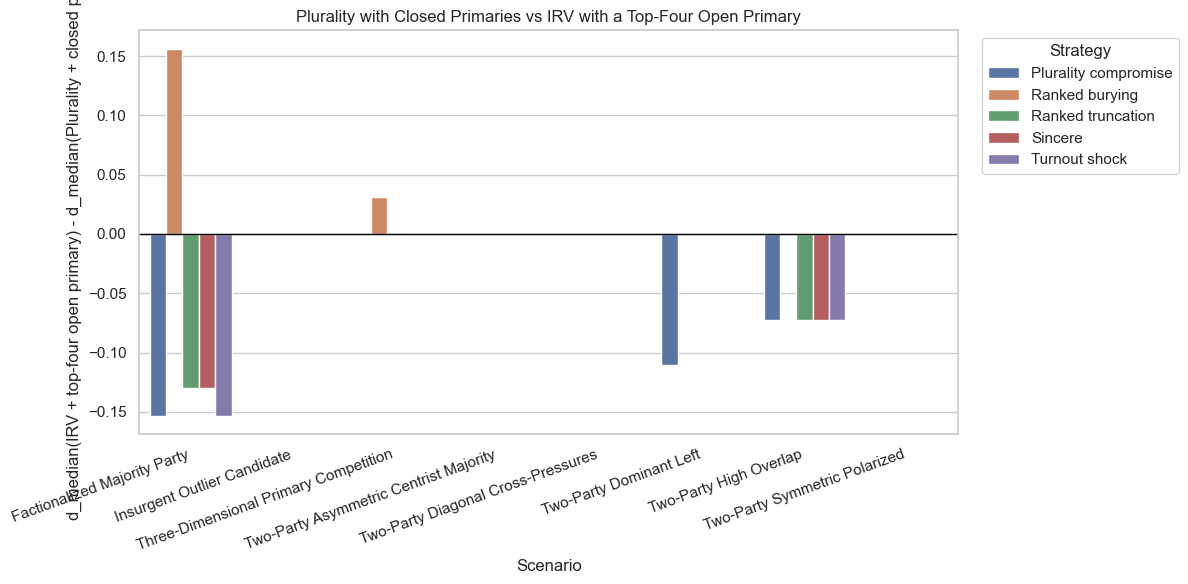

In [7]:
plot_df = summary.sort_values(["scenario", "strategy"]).copy()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=plot_df,
    x="scenario",
    y="IRV_top4_open_primary_minus_plurality_closed",
    hue="strategy",
)
plt.axhline(0.0, color="black", linewidth=1.0)
plt.ylabel("d_median(IRV + top-four open primary) - d_median(Plurality + closed primary)")
plt.xlabel("Scenario")
plt.title("Plurality with Closed Primaries vs IRV with a Top-Four Open Primary")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Strategy", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


---
## 7. Winners and finalists

This table shows which candidate wins under each pipeline and, for the top-four open-primary pipeline, which four candidates advance to the IRV general election.


In [8]:
winner_table = (
    df.pivot_table(
        index=["scenario", "strategy"],
        columns="pipeline",
        values="winner",
        aggfunc="first",
    )
    .reset_index()
)

finalist_table = (
    df.loc[
        df["pipeline"] == "IRV + top-four open primary",
        ["scenario", "strategy", "finalists", "finalist_divergence"],
    ]
    .sort_values(["scenario", "strategy"])
    .reset_index(drop=True)
)

winner_table.merge(finalist_table, on=["scenario", "strategy"], how="left")


,scenario,strategy,IRV + top-four open primary,Plurality + closed primary,finalists,finalist_divergence
0,Factionalized Majority Party,Plurality compromise,L-Governing-Moderate,Left Party nominee (L-Labor),"L-Center-Left, L-Labor, L-Movement, L-Governin...",0.251150
1,Factionalized Majority Party,Ranked burying,R-Conservative,Left Party nominee (L-Labor),"L-Labor, L-Center-Left, R-Conservative, L-Move...",0.409122
2,Factionalized Majority Party,Ranked truncation,L-Center-Left,Left Party nominee (L-Labor),"L-Labor, L-Center-Left, R-Conservative, L-Move...",0.409122
3,Factionalized Majority Party,Sincere,L-Center-Left,Left Party nominee (L-Labor),"L-Labor, L-Center-Left, R-Conservative, L-Move...",0.409122
4,Factionalized Majority Party,Turnout shock,L-Governing-Moderate,Left Party nominee (L-Labor),"L-Labor, L-Center-Left, L-Movement, L-Governin...",0.251150
5,Insurgent Outlier Candidate,Plurality compromise,L-Moderate,Left Party nominee (L-Moderate),"L-Moderate, R-Conservative, R-Moderate, L-Prog...",0.346310
6,Insurgent Outlier Candidate,Ranked burying,L-Moderate,Left Party nominee (L-Moderate),"R-Conservative, R-Moderate, L-Moderate, R-Insu...",0.386875
7,Insurgent Outlier Candidate,Ranked truncation,L-Moderate,Left Party nominee (L-Moderate),"R-Conservative, R-Moderate, L-Moderate, R-Insu...",0.386875
8,Insurgent Outlier Candidate,Sincere,L-Moderate,Left Party nominee (L-Moderate),"R-Conservative, R-Moderate, L-Moderate, R-Insu...",0.386875
9,Insurgent Outlier Candidate,Turnout shock,L-Moderate,Left Party nominee (L-Moderate),"R-Conservative, R-Moderate, L-Moderate, L-Prog...",0.346310


---
## 8. Interpretation

Across the 8 scenarios and 5 strategy profiles in this notebook, **IRV + top-four open primary** is **closer to the geometric median in 9 of 40 comparisons**, **ties in 29**, and **does worse in 2**. The strongest gains appear in only a few settings. The top-four pipeline performs best in **Factionalized Majority Party** for four of the five strategies, in **Two-Party High Overlap** for four of the five strategies, and in **Two-Party Dominant Left** under **Plurality compromise**. In those cases, the open primary can keep multiple same-side contenders alive long enough for IRV to select a candidate such as `L-Center-Left`, `L-Governing-Moderate`, or `L-Moderate` who is closer to the electorate's center than the closed-primary plurality winner.


There are also two cases where the top-four pipeline is worse: **Factionalized Majority Party** under **Ranked burying**, and **Three-Dimensional Primary Competition** under **Ranked burying**. In both cases, the strategic environment changes who sneaks into the finalist set, and the IRV stage then produces a winner farther from the geometric median than the closed-primary benchmark. 